In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import bernoulli
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import lognorm
from scipy.stats import powerlaw

from scipy.stats import probplot
from scipy.stats import boxcox
from scipy.stats import zscore
from scipy.stats import norm

In [6]:
df = pd.read_csv(r"/content/Spreadlocate.csv")
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [8]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    object 
 1   customer_id         220 non-null    object 
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    object 
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    object 
 6   transaction_status  220 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 12.2+ KB


,0
transaction_id,0
customer_id,0
transaction_amount,0
transaction_date,0
transaction_count,0
region,0
transaction_status,0


In [9]:
df.describe()

,transaction_amount,transaction_count
count,220.000000,220.000000
mean,3365.192409,2.854545
std,1985.705409,1.797189
min,804.420000,0.000000
25%,2124.205000,1.750000
50%,3077.715000,3.000000
75%,3950.737500,4.000000
max,20462.840000,9.000000


**PART A THEORY QUESTION ANSWERS**

1. What are Statistical Distributions?

A statistical distribution describes how data values are spread in a dataset and shows the probability of different outcomes. It helps in understanding data behavior, identifying patterns, predicting future results, and detecting anomalies. Statistical distributions are mainly divided into discrete and continuous distributions.

2. What is a Q-Q Plot and why is it used?

A Q-Q Plot is a graphical method used to compare a dataset with a theoretical distribution such as the Normal distribution. It is mainly used to check whether data is normally distributed, detect skewness, and identify outliers. If the plotted points form a straight line, the data is normally distributed.

3. Difference between Discrete and Continuous Distributions

Discrete distribution deals with countable values such as the number of transactions, while continuous distribution deals with measurable values such as transaction amounts. Discrete distributions use PMF whereas continuous distributions use PDF.

4. What is Bernoulli Distribution?

Bernoulli Distribution is a probability distribution that has only two possible outcomes: success and failure. It is commonly used to represent situations like transaction success or transaction failure. The probability of success is represented by p and failure by 1-p.

5. What is Binomial Distribution?

Binomial Distribution represents the number of successful outcomes in multiple Bernoulli trials. It is used when the number of trials and probability of success remain fixed. For example, it can calculate the probability of getting 8 successful transactions out of 10 attempts.

6. Explain Log-Normal Distribution.

Log-Normal Distribution occurs when the logarithm of a variable follows a Normal distribution. It is positively skewed and always contains positive values. This distribution is commonly used for financial and transaction data because transaction amounts are usually right-skewed.

7. Explain Power Law Distribution.

Power Law Distribution describes data where small values occur frequently while very large values occur rarely. It is useful in e-commerce and business analysis where a small number of customers contribute very high sales or revenue.

8. What is Box-Cox Transform?

Box-Cox Transformation is a statistical technique used to reduce skewness and stabilize variance in data. It helps transform non-normal data into data that is closer to a Normal distribution, improving statistical analysis and model performance.

9. Explain Poisson Distribution with an example.

Poisson Distribution models the number of events occurring within a fixed interval of time or space. It is commonly used for counting events such as daily transactions. For example, it can calculate the probability of receiving exactly 20 transactions in a day.

10. What is Z-score Probability?

Z-score measures how far a data value is from the mean in terms of standard deviations. It is used to identify outliers, compare data points, and calculate probabilities. A positive Z-score indicates a value above the mean, while a negative Z-score indicates a value below the mean.

11. Differentiate Probability Density Function (PDF) and Cumulative Distribution Function (CDF).

PDF represents the probability density of a continuous variable at a specific point, while CDF represents the cumulative probability up to a certain value. PDF is used to understand the distribution shape, whereas CDF shows the total probability accumulated up to a point.

**PART B — PRACTICAL IMPLEMENTATION**

Probability of Success: 0.44545454545454544


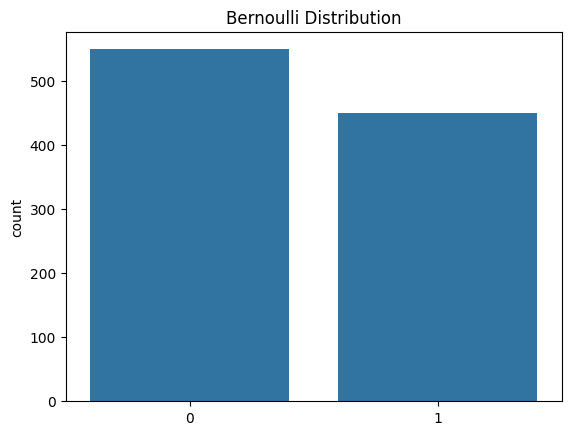

In [14]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['status_encoded'] = df['transaction_status'].map({
    'Success':1,
    'Fail':0
})
p = df['status_encoded'].mean()

print("Probability of Success:", p)

bernoulli_sample = bernoulli.rvs(p, size=1000)

sns.countplot(x=bernoulli_sample)

plt.title("Bernoulli Distribution")
plt.show()

In [15]:
df = df.drop_duplicates()

In [17]:
df['transaction_binary'] = df['transaction_status'].map({
    'Success': 1,
    'Fail': 0
})
p_success = df['transaction_binary'].mean()
print('Probability of Success:', p_success)

Probability of Success: 0.44545454545454544


In [18]:
n = 10
k = 8
p = p_success
binomial_prob = binom.pmf(k, n, p)
print('Binomial Probability:', binomial_prob)

Binomial Probability: 0.021454281390035582


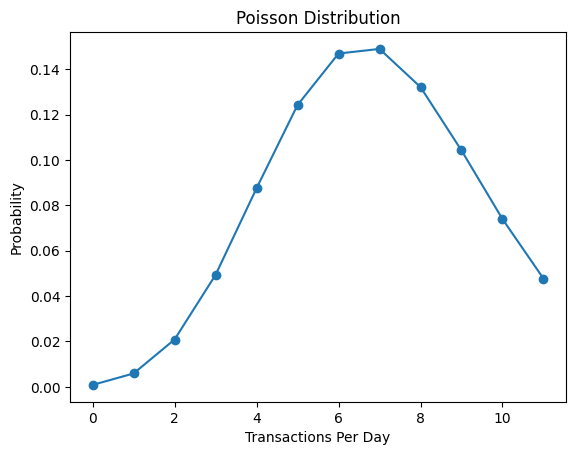

In [38]:
daily_transactions = df.groupby('transaction_date').size()
lam = daily_transactions.mean()

x = np.arange(0, daily_transactions.max())

poisson_probs = poisson.pmf(x, lam)

plt.plot(x, poisson_probs, marker='o')

plt.title("Poisson Distribution")
plt.xlabel("Transactions Per Day")
plt.ylabel("Probability")

plt.show()

In [20]:
daily_transactions = df.groupby('transaction_date').size()
lambda_value = daily_transactions.mean()
print('Lambda:', lambda_value)
poisson_prob = poisson.pmf(20, lambda_value)
print('Poisson Probability:', poisson_prob)

Lambda: 7.096774193548387
Poisson Probability: 3.57277158173636e-05


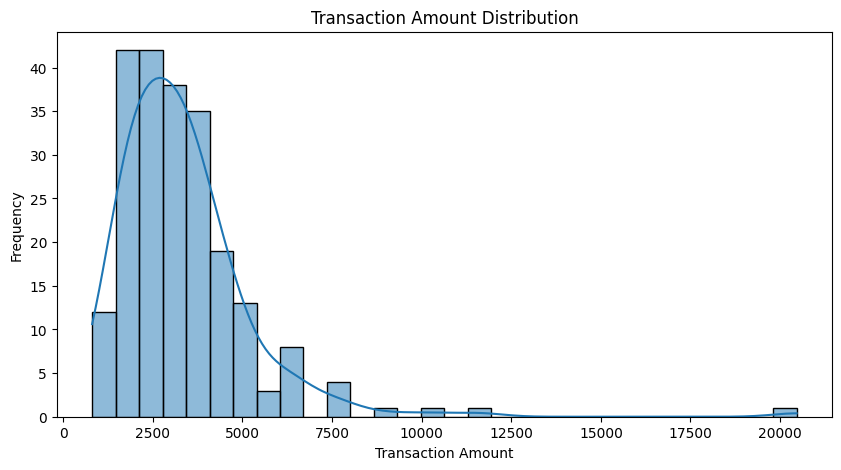

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df['transaction_amount'], bins=30, kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

In [22]:
shape, loc, scale = lognorm.fit(df['transaction_amount'])
print('Shape:', shape)
print('Location:', loc)
print('Scale:', scale)

Shape: 0.5416831487801056
Location: 333.7722748609052
Scale: 2604.740667049811


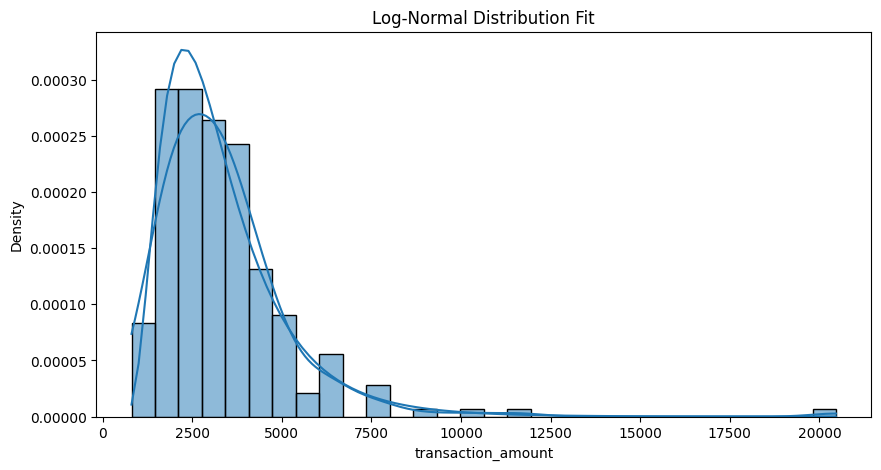

In [23]:
x = np.linspace(
    df['transaction_amount'].min(),
    df['transaction_amount'].max(),
    100
)
pdf = lognorm.pdf(x, shape, loc, scale)
plt.figure(figsize=(10,5))
sns.histplot(
    df['transaction_amount'],
    bins=30,
    stat='density',
    kde=True
)
plt.plot(x, pdf)
plt.title('Log-Normal Distribution Fit')
plt.show()

In [24]:
normalized_data = df['transaction_amount'] / df['transaction_amount'].max()
params = powerlaw.fit(normalized_data)
print('Power Law Parameters:', params)

Power Law Parameters: (np.float64(0.41249511527826355), np.float64(0.039311258847745466), np.float64(0.9606887411522547))


Text(0.5, 1.0, 'Q-Q Plot')

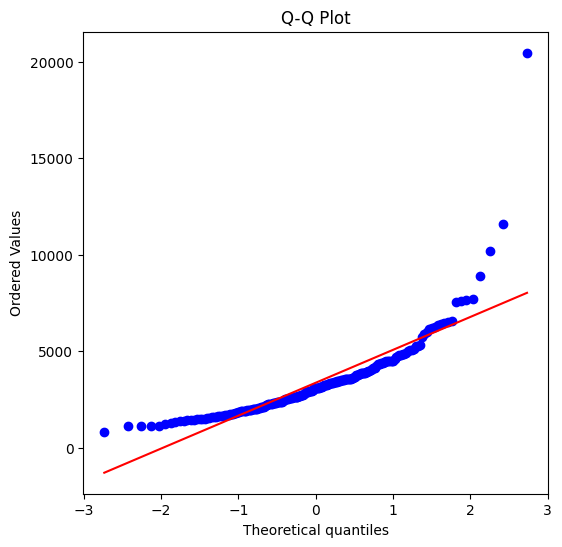

In [26]:
plt.figure(figsize=(6,6))
probplot(df['transaction_amount'], plot=plt, dist='norm')
plt.title('Q-Q Plot')

In [28]:
transformed_data, lambda_value = boxcox(df['transaction_amount'])
print('Lambda Value:', lambda_value)

Lambda Value: -0.18083390743966327


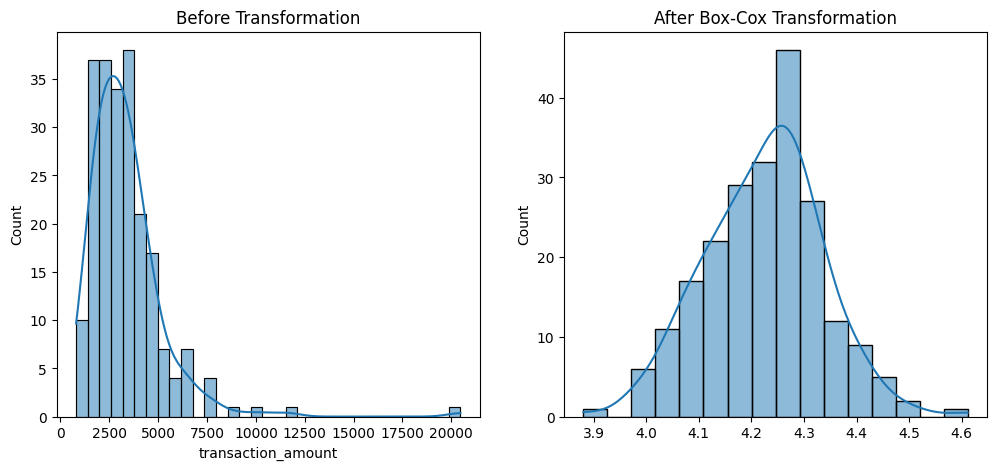

In [29]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.histplot(df['transaction_amount'], kde=True, ax=ax[0])
ax[0].set_title('Before Transformation')
sns.histplot(transformed_data, kde=True, ax=ax[1])
ax[1].set_title('After Box-Cox Transformation')
plt.show()

In [30]:
df['z_score'] = zscore(df['transaction_amount'])
print(df[['transaction_amount', 'z_score']].head())

   transaction_amount   z_score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179


In [32]:
mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()
z = (5000 - mean) / std
probability = 1 - norm.cdf(z)
print('Probability of Transaction > ₹5000:', probability)

Probability of Transaction > ₹5000: 0.20517209567554384


In [34]:
mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()
x = np.linspace(
    df['transaction_amount'].min(),
    df['transaction_amount'].max(),
    100
)
pdf = norm.pdf(x, mean, std)

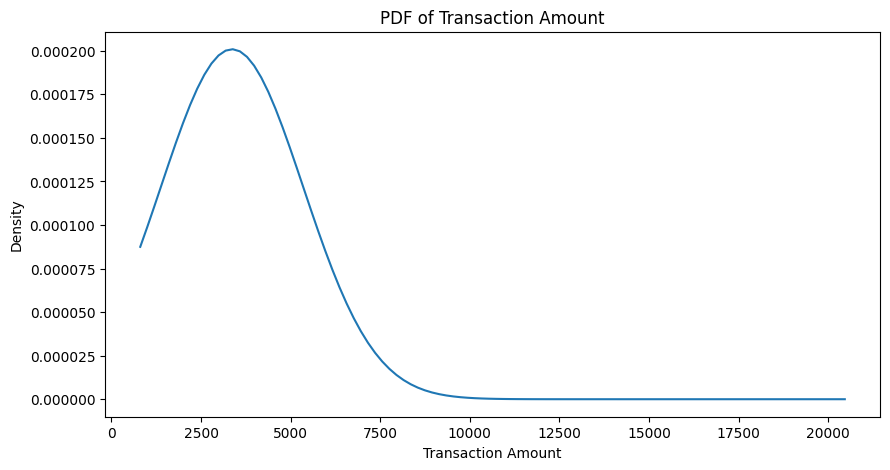

In [35]:
plt.figure(figsize=(10,5))
plt.plot(x, pdf)
plt.title('PDF of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.show()

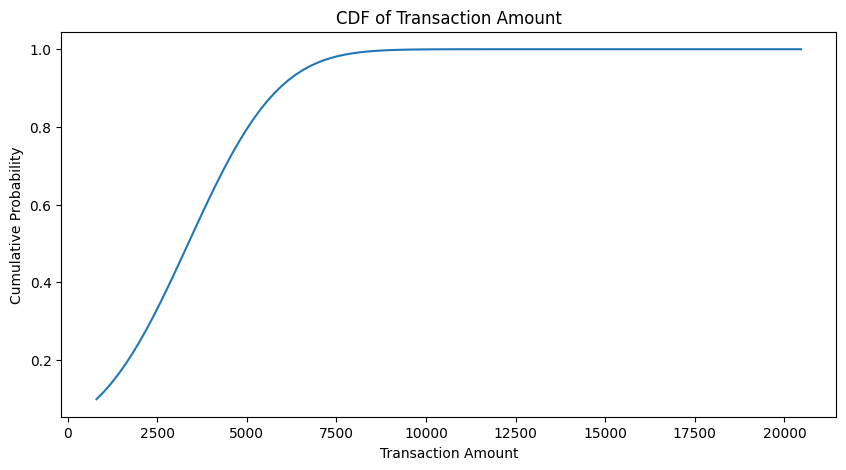

In [37]:
cdf = norm.cdf(x, mean, std)
plt.figure(figsize=(10,5))
plt.plot(x, cdf)
plt.title('CDF of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Cumulative Probability')
plt.show()